# 04 — TF-IDF Controlled Experiments

In this notebook, we improve the traditional NLP baseline using
controlled experiments.

## Experiment 1

Question:

Does adding bigram features improve sentiment classification compared
with unigram-only TF-IDF?

Baseline:

- `ngram_range=(1, 1)`

Experiment:

- `ngram_range=(1, 2)`

All other TF-IDF settings and model-training settings remain unchanged.

Important:

Model selection is based only on the validation set.
The test set is not used in this notebook.

In [1]:
from __future__ import annotations

from pathlib import Path
import copy
import sys
import time

import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

from torch import nn

from torch.utils.data import (
    DataLoader,
    Dataset,
)

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers


In [3]:
try:
    from src.predict_tfidf import (
        LogisticRegressionModel,
        clean_text_for_model,
    )
except ModuleNotFoundError:
    from predict_tfidf import (
        LogisticRegressionModel,
        clean_text_for_model,
    )

In [4]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

EXPERIMENT_REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tfidf_experiments"
)

EXPERIMENT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Data:",
    DATA_PATH,
)

print(
    "Reports:",
    EXPERIMENT_REPORT_DIR,
)

Data: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\data\processed\imdb_clean_splits
Reports: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\reports\tfidf_experiments


In [5]:
RANDOM_SEED = 42

np.random.seed(
    RANDOM_SEED
)

torch.manual_seed(
    RANDOM_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)

Device: cuda


## 2. Load train and validation data

Only training and validation splits are used for experiments.

The official test set remains untouched.

In [6]:
dataset = load_from_disk(
    str(DATA_PATH)
)

train_df = (
    dataset["train"]
    .to_pandas()[["text", "label"]]
    .copy()
)

validation_df = (
    dataset["validation"]
    .to_pandas()[["text", "label"]]
    .copy()
)

print(
    "Train rows:",
    f"{len(train_df):,}",
)

print(
    "Validation rows:",
    f"{len(validation_df):,}",
)

Train rows: 19,823
Validation rows: 4,956


In [7]:
train_texts = (
    train_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

validation_texts = (
    validation_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

y_train = train_df[
    "label"
].to_numpy(
    dtype=np.float32
)

y_validation = validation_df[
    "label"
].to_numpy(
    dtype=np.float32
)

print(
    "Training texts:",
    len(train_texts),
)

print(
    "Validation texts:",
    len(validation_texts),
)

Training texts: 19823
Validation texts: 4956


In [8]:
COMMON_VECTORIZER_SETTINGS = {
    "lowercase": True,
    "min_df": 2,
    "max_df": 0.95,
    "max_features": 20_000,
    "sublinear_tf": True,
    "dtype": np.float32,
}

In [9]:
EXPERIMENTS = [
    {
        "name": "unigram",
        "ngram_range": (1, 1),
    },
    {
        "name": "unigram_bigram",
        "ngram_range": (1, 2),
    },
]

experiments_df = pd.DataFrame(
    EXPERIMENTS
)

experiments_df

,name,ngram_range
0,unigram,"(1, 1)"
1,unigram_bigram,"(1, 2)"


## 3. Shared training configuration

All experiments use the same model-training settings.

This ensures that the TF-IDF representation is the only variable
we intentionally change.

In [10]:
BATCH_SIZE = 128
NUMBER_OF_EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

### Sparse-matrix Dataset

The TF-IDF matrices are sparse and remain outside the PyTorch Dataset.

The Dataset stores only row indices and labels.

In [11]:
class RowIndexDataset(Dataset):
    def __init__(
        self,
        labels: np.ndarray,
    ) -> None:
        self.labels = np.asarray(
            labels,
            dtype=np.float32,
        )

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(
        self,
        index: int,
    ) -> tuple[int, np.float32]:
        return index, self.labels[index]

In [12]:
def create_collate_function(
    sparse_matrix,
):
    def collate_batch(batch):
        indices = np.asarray(
            [
                item[0]
                for item in batch
            ],
            dtype=np.int64,
        )

        labels = np.asarray(
            [
                item[1]
                for item in batch
            ],
            dtype=np.float32,
        )

        dense_features = (
            sparse_matrix[indices]
            .toarray()
            .astype(
                np.float32,
                copy=False,
            )
        )

        feature_tensor = torch.from_numpy(
            dense_features
        )

        label_tensor = torch.from_numpy(
            labels
        )

        return (
            feature_tensor,
            label_tensor,
        )

    return collate_batch

In [13]:
def create_data_loaders(
    X_train,
    y_train: np.ndarray,
    X_validation,
    y_validation: np.ndarray,
    batch_size: int,
) -> tuple[DataLoader, DataLoader]:

    train_dataset = RowIndexDataset(
        y_train
    )

    validation_dataset = RowIndexDataset(
        y_validation
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=create_collate_function(
            X_train
        ),
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=create_collate_function(
            X_validation
        ),
    )

    return (
        train_loader,
        validation_loader,
    )

### Validation evaluation

This function evaluates a model without updating its weights.

It returns validation loss, accuracy, precision, recall, and F1.

In [14]:
@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict[str, float]:

    model.eval()

    total_loss = 0.0

    all_probabilities = []
    all_labels = []

    for features, labels in data_loader:
        features = features.to(
            device
        )

        labels = labels.to(
            device
        )

        logits = model(
            features
        )

        loss = loss_function(
            logits,
            labels,
        )

        probabilities = torch.sigmoid(
            logits
        )

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        all_probabilities.append(
            probabilities.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

    probabilities = torch.cat(
        all_probabilities
    ).numpy()

    labels = torch.cat(
        all_labels
    ).numpy().astype(int)

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
    }

In [18]:
def reset_random_seed(
    seed: int = RANDOM_SEED,
) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 4. Train one controlled experiment

The function below performs the complete experiment pipeline:

1. Create the TF-IDF vectorizer.
2. Fit it only on training text.
3. Transform validation text.
4. Create PyTorch DataLoaders.
5. Create a fresh logistic-regression model.
6. Train the model.
7. Evaluate validation performance after every epoch.
8. Keep the checkpoint with the best validation F1.
9. Return the trained model, vectorizer, history, and summary.

In [19]:
def train_one_experiment(
    name: str,
    ngram_range: tuple[int, int],
) -> dict[str, object]:

    print("=" * 70)
    print("Experiment:", name)
    print("ngram_range:", ngram_range)
    print("=" * 70)

    # -----------------------------------------------------
    # 1. Reset randomness
    # -----------------------------------------------------

    reset_random_seed()

    experiment_start = time.perf_counter()

    # -----------------------------------------------------
    # 2. Create TF-IDF vectorizer
    # -----------------------------------------------------

    vectorizer = TfidfVectorizer(
        **COMMON_VECTORIZER_SETTINGS,
        ngram_range=ngram_range,
    )

    # -----------------------------------------------------
    # 3. Fit training text and transform validation text
    # -----------------------------------------------------

    vectorization_start = time.perf_counter()

    X_train = vectorizer.fit_transform(
        train_texts
    )

    X_validation = vectorizer.transform(
        validation_texts
    )

    vectorization_seconds = (
        time.perf_counter()
        - vectorization_start
    )

    print(
        "Train matrix:",
        X_train.shape,
    )

    print(
        "Validation matrix:",
        X_validation.shape,
    )

    print(
        "Vectorization time:",
        f"{vectorization_seconds:.2f}s",
    )

    # -----------------------------------------------------
    # 4. Inspect sparsity
    # -----------------------------------------------------

    total_values = (
        X_train.shape[0]
        * X_train.shape[1]
    )

    density = (
        X_train.nnz
        / total_values
    )

    print(
        "Non-zero values:",
        f"{X_train.nnz:,}",
    )

    print(
        "Density:",
        f"{density:.6%}",
    )

    # -----------------------------------------------------
    # 5. Create DataLoaders
    # -----------------------------------------------------

    train_loader, validation_loader = (
        create_data_loaders(
            X_train=X_train,
            y_train=y_train,
            X_validation=X_validation,
            y_validation=y_validation,
            batch_size=BATCH_SIZE,
        )
    )

    # -----------------------------------------------------
    # 6. Create a fresh model
    # -----------------------------------------------------

    model = LogisticRegressionModel(
        number_of_features=X_train.shape[1]
    ).to(device)

    loss_function = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    # -----------------------------------------------------
    # 7. Prepare best-checkpoint tracking
    # -----------------------------------------------------

    best_validation_f1 = -1.0
    best_model_state = None
    best_epoch = None

    training_history = []

    training_start = time.perf_counter()

    # -----------------------------------------------------
    # 8. Training loop
    # -----------------------------------------------------

    for epoch in range(
        1,
        NUMBER_OF_EPOCHS + 1,
    ):
        model.train()

        epoch_start = time.perf_counter()

        total_training_loss = 0.0

        for features, labels in train_loader:
            features = features.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad()

            logits = model(
                features
            )

            loss = loss_function(
                logits,
                labels,
            )

            loss.backward()

            optimizer.step()

            total_training_loss += (
                loss.item()
                * labels.size(0)
            )

        average_training_loss = (
            total_training_loss
            / len(train_loader.dataset)
        )

        # ---------------------------------------------
        # Validate after this epoch
        # ---------------------------------------------

        validation_results = evaluate_model(
            model=model,
            data_loader=validation_loader,
            loss_function=loss_function,
            device=device,
        )

        epoch_seconds = (
            time.perf_counter()
            - epoch_start
        )

        # ---------------------------------------------
        # Store the epoch history
        # ---------------------------------------------

        epoch_record = {
            "experiment": name,
            "epoch": epoch,
            "train_loss": average_training_loss,
            "validation_loss": (
                validation_results["loss"]
            ),
            "validation_accuracy": (
                validation_results["accuracy"]
            ),
            "validation_precision": (
                validation_results["precision"]
            ),
            "validation_recall": (
                validation_results["recall"]
            ),
            "validation_f1": (
                validation_results["f1"]
            ),
            "seconds": epoch_seconds,
        }

        training_history.append(
            epoch_record
        )

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: "
            f"{average_training_loss:.4f} | "
            f"Val Loss: "
            f"{validation_results['loss']:.4f} | "
            f"Val Accuracy: "
            f"{validation_results['accuracy']:.4f} | "
            f"Val F1: "
            f"{validation_results['f1']:.4f} | "
            f"Time: {epoch_seconds:.1f}s"
        )

        # ---------------------------------------------
        # Save the best model
        # ---------------------------------------------

        if (
            validation_results["f1"]
            > best_validation_f1
        ):
            best_validation_f1 = (
                validation_results["f1"]
            )

            best_epoch = epoch

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    # -----------------------------------------------------
    # 9. Restore best checkpoint
    # -----------------------------------------------------

    if best_model_state is None:
        raise RuntimeError(
            "No model checkpoint was saved."
        )

    model.load_state_dict(
        best_model_state
    )

    # -----------------------------------------------------
    # 10. Evaluate the restored best model
    # -----------------------------------------------------

    best_validation_results = evaluate_model(
        model=model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device,
    )

    total_experiment_seconds = (
        time.perf_counter()
        - experiment_start
    )

    # -----------------------------------------------------
    # 11. Build summary
    # -----------------------------------------------------

    summary = {
        "experiment": name,
        "ngram_min": ngram_range[0],
        "ngram_max": ngram_range[1],
        "number_of_features": (
            X_train.shape[1]
        ),
        "train_non_zero_values": (
            X_train.nnz
        ),
        "train_density": density,
        "vectorization_seconds": (
            vectorization_seconds
        ),
        "training_seconds": (
            training_seconds
        ),
        "total_seconds": (
            total_experiment_seconds
        ),
        "best_epoch": best_epoch,
        "validation_accuracy": (
            best_validation_results[
                "accuracy"
            ]
        ),
        "validation_precision": (
            best_validation_results[
                "precision"
            ]
        ),
        "validation_recall": (
            best_validation_results[
                "recall"
            ]
        ),
        "validation_f1": (
            best_validation_results[
                "f1"
            ]
        ),
    }

    print()
    print(
        "Best epoch:",
        best_epoch,
    )

    print(
        "Best validation F1:",
        f"{best_validation_f1:.4f}",
    )

    return {
        "name": name,
        "vectorizer": vectorizer,
        "model": model,
        "history": pd.DataFrame(
            training_history
        ),
        "summary": summary,
    }

## 5. Run the unigram + bigram experiment

Now we keep the entire training pipeline unchanged and modify only
the TF-IDF n-gram range.

Baseline:

```python
ngram_range=(1, 1)

In [21]:
unigram_bigram_result = train_one_experiment(
    name="unigram_bigram",
    ngram_range=(1, 2),
)

Experiment: unigram_bigram
ngram_range: (1, 2)
Train matrix: (19823, 20000)
Validation matrix: (4956, 20000)
Vectorization time: 11.74s
Non-zero values: 4,128,409
Density: 1.041318%
Epoch 01 | Train Loss: 0.6656 | Val Loss: 0.6384 | Val Accuracy: 0.8622 | Val F1: 0.8617 | Time: 1.8s
Epoch 02 | Train Loss: 0.6115 | Val Loss: 0.5931 | Val Accuracy: 0.8660 | Val F1: 0.8683 | Time: 2.0s
Epoch 03 | Train Loss: 0.5666 | Val Loss: 0.5554 | Val Accuracy: 0.8682 | Val F1: 0.8692 | Time: 1.9s
Epoch 04 | Train Loss: 0.5288 | Val Loss: 0.5235 | Val Accuracy: 0.8699 | Val F1: 0.8715 | Time: 2.0s
Epoch 05 | Train Loss: 0.4966 | Val Loss: 0.4965 | Val Accuracy: 0.8737 | Val F1: 0.8765 | Time: 1.5s
Epoch 06 | Train Loss: 0.4690 | Val Loss: 0.4731 | Val Accuracy: 0.8753 | Val F1: 0.8782 | Time: 1.5s
Epoch 07 | Train Loss: 0.4448 | Val Loss: 0.4529 | Val Accuracy: 0.8789 | Val F1: 0.8812 | Time: 1.8s
Epoch 08 | Train Loss: 0.4236 | Val Loss: 0.4352 | Val Accuracy: 0.8803 | Val F1: 0.8829 | Time: 1.9s

B

## 6. Compare the experiments

We compare validation quality and computational cost.

The test set is still not used.

In [27]:
unigram_bigram_result[
    "summary"
]
unigram_result = train_one_experiment(
    name="unigram",
    ngram_range=(1, 1),
)

Experiment: unigram
ngram_range: (1, 1)
Train matrix: (19823, 20000)
Validation matrix: (4956, 20000)
Vectorization time: 3.28s
Non-zero values: 2,580,136
Density: 0.650794%
Epoch 01 | Train Loss: 0.6716 | Val Loss: 0.6501 | Val Accuracy: 0.8438 | Val F1: 0.8387 | Time: 2.0s
Epoch 02 | Train Loss: 0.6276 | Val Loss: 0.6129 | Val Accuracy: 0.8487 | Val F1: 0.8490 | Time: 1.8s
Epoch 03 | Train Loss: 0.5896 | Val Loss: 0.5809 | Val Accuracy: 0.8517 | Val F1: 0.8509 | Time: 1.6s
Epoch 04 | Train Loss: 0.5565 | Val Loss: 0.5530 | Val Accuracy: 0.8555 | Val F1: 0.8558 | Time: 1.8s
Epoch 05 | Train Loss: 0.5275 | Val Loss: 0.5287 | Val Accuracy: 0.8596 | Val F1: 0.8616 | Time: 1.7s
Epoch 06 | Train Loss: 0.5020 | Val Loss: 0.5072 | Val Accuracy: 0.8618 | Val F1: 0.8644 | Time: 1.7s
Epoch 07 | Train Loss: 0.4792 | Val Loss: 0.4881 | Val Accuracy: 0.8644 | Val F1: 0.8665 | Time: 2.5s
Epoch 08 | Train Loss: 0.4587 | Val Loss: 0.4712 | Val Accuracy: 0.8664 | Val F1: 0.8692 | Time: 2.5s

Best epoc

In [28]:
experiment_comparison_df = pd.DataFrame(
    [
        unigram_result[
            "summary"
        ],
        unigram_bigram_result[
            "summary"
        ],
    ]
)

experiment_comparison_df

,experiment,ngram_min,ngram_max,number_of_features,train_non_zero_values,train_density,vectorization_seconds,training_seconds,total_seconds,best_epoch,validation_accuracy,validation_precision,validation_recall,validation_f1
0,unigram,1,1,20000,2580136,0.006508,3.284562,15.688845,19.362995,8,0.866425,0.855033,0.883889,0.869222
1,unigram_bigram,1,2,20000,4128409,0.010413,11.743551,14.402152,28.989594,8,0.880347,0.868012,0.898353,0.882922


In [29]:
comparison_columns = [
    "experiment",
    "number_of_features",
    "train_non_zero_values",
    "train_density",
    "vectorization_seconds",
    "training_seconds",
    "best_epoch",
    "validation_accuracy",
    "validation_precision",
    "validation_recall",
    "validation_f1",
]

experiment_comparison_df[
    comparison_columns
]

,experiment,number_of_features,train_non_zero_values,train_density,vectorization_seconds,training_seconds,best_epoch,validation_accuracy,validation_precision,validation_recall,validation_f1
0,unigram,20000,2580136,0.006508,3.284562,15.688845,8,0.866425,0.855033,0.883889,0.869222
1,unigram_bigram,20000,4128409,0.010413,11.743551,14.402152,8,0.880347,0.868012,0.898353,0.882922


In [30]:
unigram_summary = unigram_result[
    "summary"
]

bigram_summary = unigram_bigram_result[
    "summary"
]

delta_validation_f1 = (
    bigram_summary["validation_f1"]
    - unigram_summary["validation_f1"]
)

delta_validation_accuracy = (
    bigram_summary["validation_accuracy"]
    - unigram_summary["validation_accuracy"]
)

delta_vectorization_seconds = (
    bigram_summary["vectorization_seconds"]
    - unigram_summary["vectorization_seconds"]
)

delta_training_seconds = (
    bigram_summary["training_seconds"]
    - unigram_summary["training_seconds"]
)

print(
    "Δ Validation F1:",
    f"{delta_validation_f1:+.4f}",
)

print(
    "Δ Validation Accuracy:",
    f"{delta_validation_accuracy:+.4f}",
)

print(
    "Δ Vectorization time:",
    f"{delta_vectorization_seconds:+.2f}s",
)

print(
    "Δ Training time:",
    f"{delta_training_seconds:+.2f}s",
)

Δ Validation F1: +0.0137
Δ Validation Accuracy: +0.0139
Δ Vectorization time: +8.46s
Δ Training time: -1.29s


In [31]:
relative_f1_improvement = (
    delta_validation_f1
    / unigram_summary[
        "validation_f1"
    ]
)

print(
    "Relative F1 improvement:",
    f"{relative_f1_improvement:.2%}",
)

Relative F1 improvement: 1.58%


In [32]:
unigram_history = (
    unigram_result[
        "history"
    ]
    .copy()
)

bigram_history = (
    unigram_bigram_result[
        "history"
    ]
    .copy()
)

combined_history_df = pd.concat(
    [
        unigram_history,
        bigram_history,
    ],
    ignore_index=True,
)

combined_history_df[
    [
        "experiment",
        "epoch",
        "train_loss",
        "validation_loss",
        "validation_accuracy",
        "validation_f1",
    ]
]

,experiment,epoch,train_loss,validation_loss,validation_accuracy,validation_f1
0,unigram,1,0.671606,0.650065,0.843826,0.838683
1,unigram,2,0.627601,0.612905,0.848668,0.849034
2,unigram,3,0.589592,0.580889,0.851695,0.850943
3,unigram,4,0.556545,0.553021,0.855529,0.855820
4,unigram,5,0.527512,0.528664,0.859564,0.861630
5,unigram,6,0.501950,0.507186,0.861784,0.864383
6,unigram,7,0.479152,0.488130,0.864407,0.866508
7,unigram,8,0.458748,0.471194,0.866425,0.869222
8,unigram_bigram,1,0.665562,0.638405,0.862187,0.861657
9,unigram_bigram,2,0.611522,0.593084,0.866021,0.868254


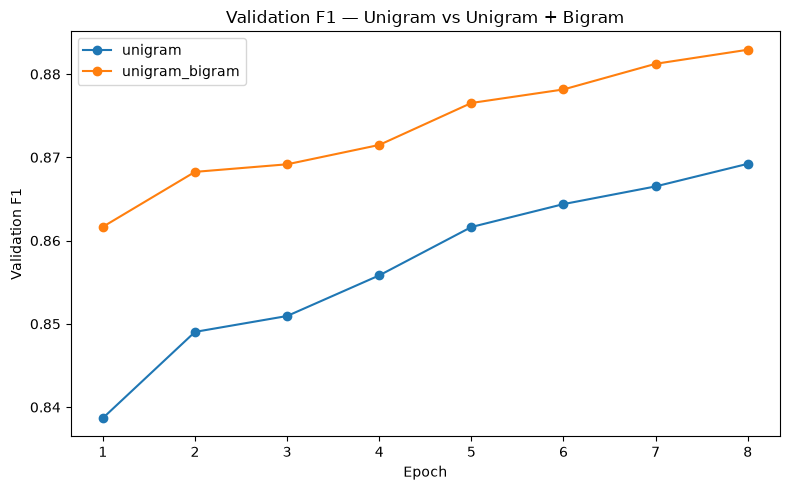

In [33]:
import matplotlib.pyplot as plt
plt.figure(
    figsize=(8, 5)
)

for experiment_name, history in (
    combined_history_df
    .groupby("experiment")
):
    plt.plot(
        history["epoch"],
        history["validation_f1"],
        marker="o",
        label=experiment_name,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation F1")

plt.title(
    "Validation F1 — Unigram vs Unigram + Bigram"
)

plt.legend()

plt.tight_layout()

plt.show()

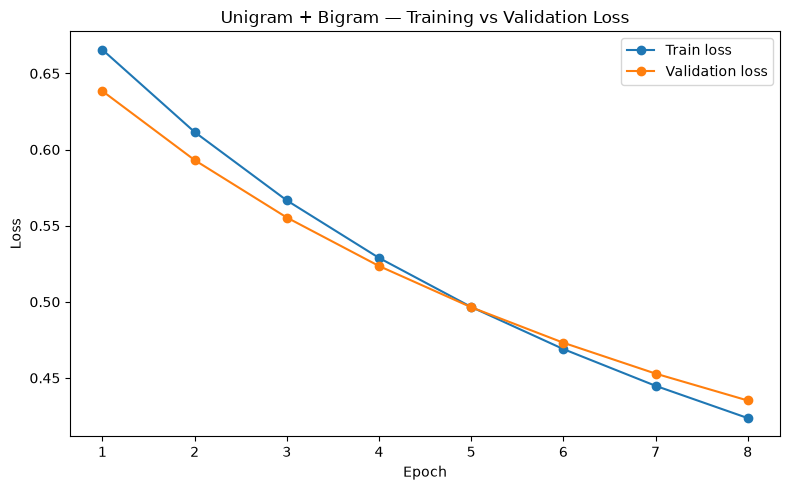

In [34]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    bigram_history["epoch"],
    bigram_history["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    bigram_history["epoch"],
    bigram_history["validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Unigram + Bigram — Training vs Validation Loss"
)

plt.legend()
plt.tight_layout()
plt.show()

In [35]:
bigram_vectorizer = (
    unigram_bigram_result[
        "vectorizer"
    ]
)

bigram_feature_names = (
    bigram_vectorizer
    .get_feature_names_out()
)

example_bigram_features = [
    feature
    for feature in bigram_feature_names
    if " " in feature
][:30]

example_bigram_features

['10 10',
 '10 and',
 '10 because',
 '10 but',
 '10 for',
 '10 it',
 '10 minutes',
 '10 out',
 '10 stars',
 '10 the',
 '10 year',
 '10 years',
 '12 year',
 '14 year',
 '15 minutes',
 '15 years',
 '19th century',
 '20 minutes',
 '20 years',
 '20th century',
 '21st century',
 '25 years',
 '30 minutes',
 '30 years',
 '40 minutes',
 '40 year',
 '40 years',
 '45 minutes',
 '70 and',
 '80 minutes']

In [36]:
number_of_bigrams = sum(
    " " in feature
    for feature in bigram_feature_names
)

number_of_unigrams = (
    len(bigram_feature_names)
    - number_of_bigrams
)

print(
    "Unigrams:",
    f"{number_of_unigrams:,}",
)

print(
    "Bigrams:",
    f"{number_of_bigrams:,}",
)

print(
    "Bigram share:",
    f"{number_of_bigrams / len(bigram_feature_names):.2%}",
)

Unigrams: 7,568
Bigrams: 12,432
Bigram share: 62.16%


In [37]:
if delta_validation_f1 > 0:
    print(
        "Bigram experiment improved validation F1."
    )
else:
    print(
        "Bigram experiment did not improve validation F1."
    )

Bigram experiment improved validation F1.


In [38]:
experiment_comparison_df.to_csv(
    EXPERIMENT_REPORT_DIR
    / "experiment_comparison.csv",
    index=False,
)

combined_history_df.to_csv(
    EXPERIMENT_REPORT_DIR
    / "training_histories.csv",
    index=False,
)

experiment_comparison_df.to_csv(
    EXPERIMENT_REPORT_DIR
    / "experiment_comparison.csv",
    index=False,
)

combined_history_df.to_csv(
    EXPERIMENT_REPORT_DIR
    / "training_histories.csv",
    index=False,
)

In [39]:
previous_results_df = pd.DataFrame(
    [
        unigram_result["summary"],
        unigram_bigram_result["summary"],
    ]
)

best_previous_row = (
    previous_results_df
    .sort_values(
        by="validation_f1",
        ascending=False,
    )
    .iloc[0]
)

best_ngram_range = (
    int(best_previous_row["ngram_min"]),
    int(best_previous_row["ngram_max"]),
)

print(
    "Best previous experiment:",
    best_previous_row["experiment"],
)

print(
    "Selected ngram_range:",
    best_ngram_range,
)

print(
    "Validation F1:",
    f"{best_previous_row['validation_f1']:.4f}",
)

Best previous experiment: unigram_bigram
Selected ngram_range: (1, 2)
Validation F1: 0.8829


In [41]:
COMMON_VECTORIZER_SETTINGS = {
    "lowercase": True,
    "min_df": 2,
    "max_df": 0.95,
    "max_features": 20_000,
    "sublinear_tf": True,
    "dtype": np.float32,
}

## 7. Save the best traditional model

The unigram + bigram TF-IDF representation achieved the best
validation performance.

We now save:

1. The trained PyTorch logistic-regression weights.
2. The fitted TF-IDF vectorizer.
3. Metadata describing the selected configuration.

These artifacts will later be loaded for final test evaluation
without retraining the model.

In [43]:
best_traditional_result = (
    unigram_bigram_result
)

best_traditional_model = (
    best_traditional_result[
        "model"
    ]
)

best_traditional_vectorizer = (
    best_traditional_result[
        "vectorizer"
    ]
)

best_traditional_summary = (
    best_traditional_result[
        "summary"
    ]
)

In [44]:
import joblib

In [45]:
BEST_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "best_traditional"
)

BEST_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Best model directory:",
    BEST_MODEL_DIR,
)

Best model directory: D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\models\best_traditional


In [46]:
BEST_MODEL_PATH = (
    BEST_MODEL_DIR
    / "tfidf_logistic_regression.pt"
)

BEST_VECTORIZER_PATH = (
    BEST_MODEL_DIR
    / "tfidf_vectorizer.joblib"
)

In [47]:
number_of_features = len(
    best_traditional_vectorizer
    .get_feature_names_out()
)

torch.save(
    {
        "model_state_dict": (
            best_traditional_model
            .state_dict()
        ),
        "number_of_features": (
            number_of_features
        ),
        "ngram_range": (1, 2),
        "max_features": 20_000,
        "validation_f1": (
            best_traditional_summary[
                "validation_f1"
            ]
        ),
        "validation_accuracy": (
            best_traditional_summary[
                "validation_accuracy"
            ]
        ),
        "best_epoch": (
            best_traditional_summary[
                "best_epoch"
            ]
        ),
        "random_seed": (
            RANDOM_SEED
        ),
    },
    BEST_MODEL_PATH,
)

In [48]:
joblib.dump(
    best_traditional_vectorizer,
    BEST_VECTORIZER_PATH,
)

['D:\\app\\ai\\Sentiment Analysis Traditional ML vs Transformers\\models\\best_traditional\\tfidf_vectorizer.joblib']

In [49]:
assert BEST_MODEL_PATH.exists()

assert BEST_VECTORIZER_PATH.exists()

print(
    "Model saved to:"
)

print(
    BEST_MODEL_PATH
)

print()

print(
    "Vectorizer saved to:"
)

print(
    BEST_VECTORIZER_PATH
)

Model saved to:
D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\models\best_traditional\tfidf_logistic_regression.pt

Vectorizer saved to:
D:\app\ai\Sentiment Analysis Traditional ML vs Transformers\models\best_traditional\tfidf_vectorizer.joblib


In [50]:
loaded_vectorizer = joblib.load(
    BEST_VECTORIZER_PATH
)

print(
    "Loaded vectorizer features:",
    len(
        loaded_vectorizer
        .get_feature_names_out()
    ),
)

Loaded vectorizer features: 20000


In [51]:
loaded_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

print(
    loaded_checkpoint.keys()
)

dict_keys(['model_state_dict', 'number_of_features', 'ngram_range', 'max_features', 'validation_f1', 'validation_accuracy', 'best_epoch', 'random_seed'])


In [52]:
loaded_model = LogisticRegressionModel(
    number_of_features=(
        loaded_checkpoint[
            "number_of_features"
        ]
    )
).to(device)

In [53]:
loaded_model = LogisticRegressionModel(
    number_of_features=(
        loaded_checkpoint[
            "number_of_features"
        ]
    )
).to(device)

In [54]:
loaded_model.load_state_dict(
    loaded_checkpoint[
        "model_state_dict"
    ]
)

loaded_model.eval()

LogisticRegressionModel(
  (linear): Linear(in_features=20000, out_features=1, bias=True)
)

In [55]:
loaded_feature_count = len(
    loaded_vectorizer
    .get_feature_names_out()
)

model_feature_count = (
    loaded_checkpoint[
        "number_of_features"
    ]
)

assert (
    loaded_feature_count
    == model_feature_count
)

print(
    "Model and vectorizer are compatible."
)

Model and vectorizer are compatible.
